# GuardianLens — Discord chat generator preview

Generates high-fidelity Discord chat frames for the demo video, previews them inline, and compiles them into an MP4.

**Four scenarios:** `safe`, `grooming`, `bullying`, `scam`. Each scenario renders one frame per message (progressive growth) so a short dialogue turns into a playable clip that can be fed to the app via `run.py --watch-folder`.

Run the cells top-to-bottom.

## 1. Setup

Add the project `src/` directory to `sys.path` so `guardlens` can be imported without installing it into this conda environment. Also resolve the project root so relative output paths work from any kernel working directory.

In [1]:
import os
import sys
import shutil
import subprocess
from pathlib import Path

# Project root is the parent of this notebook's directory.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Change into the project root so output paths resolve consistently.
os.chdir(PROJECT_ROOT)

print(f"project root: {PROJECT_ROOT}")
print(f"src on path : {SRC_PATH}")
print(f"ffmpeg      : {shutil.which('ffmpeg')}")

project root: /home/natalka/kaggle/kaggle-gemma4-good-hackathon
src on path : /home/natalka/kaggle/kaggle-gemma4-good-hackathon/src
ffmpeg      : /usr/bin/ffmpeg


## 2. Render all four scenarios

Each scenario produces one PNG per message, numbered `frame_0001.png`, `frame_0002.png`, ... into `outputs/video_feeds/discord_<scenario>/`. Frames before the last also show a typing indicator for the upcoming speaker.

In [2]:
from guardlens.discord_chat import SCENARIO_BUILDERS, render_scenario

FEEDS_ROOT = PROJECT_ROOT / "outputs" / "video_feeds"

rendered = {}
for name in sorted(SCENARIO_BUILDERS):
    out_dir = FEEDS_ROOT / f"discord_{name}"
    # Clean the directory first so re-runs don't leave stale frames behind.
    if out_dir.exists():
        for p in out_dir.glob("frame_*.png"):
            p.unlink()
    paths = render_scenario(name, out_dir)
    rendered[name] = paths
    print(f"  {name:10s} -> {len(paths)} frames in {out_dir.relative_to(PROJECT_ROOT)}")

  bullying   -> 8 frames in outputs/video_feeds/discord_bullying
  grooming   -> 9 frames in outputs/video_feeds/discord_grooming
  safe       -> 7 frames in outputs/video_feeds/discord_safe
  scam       -> 6 frames in outputs/video_feeds/discord_scam


## 3. Inline preview — every frame of the grooming scenario

Displays each frame at half resolution so the full 9-frame progression is readable without scrolling sideways.

### grooming — 9 frames

**Frame 1/9** — `frame_0001.png`

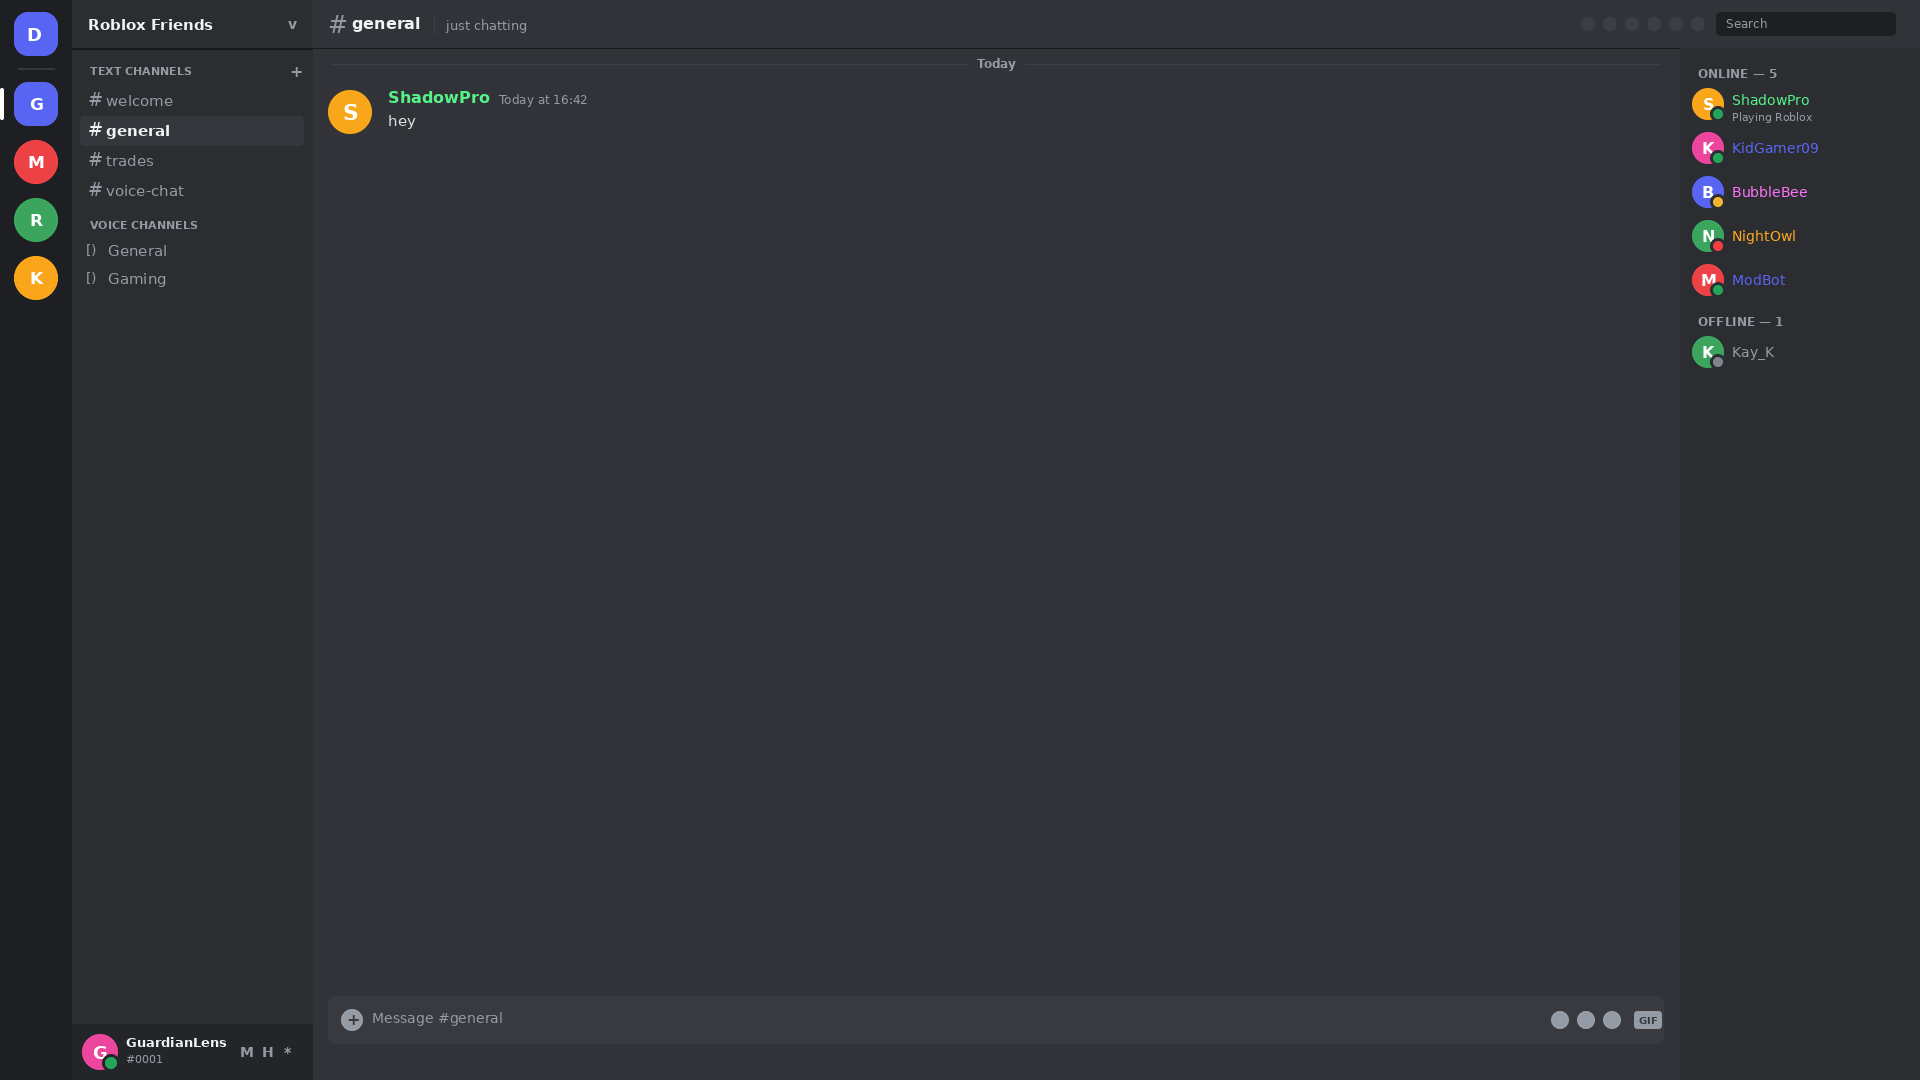

**Frame 2/9** — `frame_0002.png`

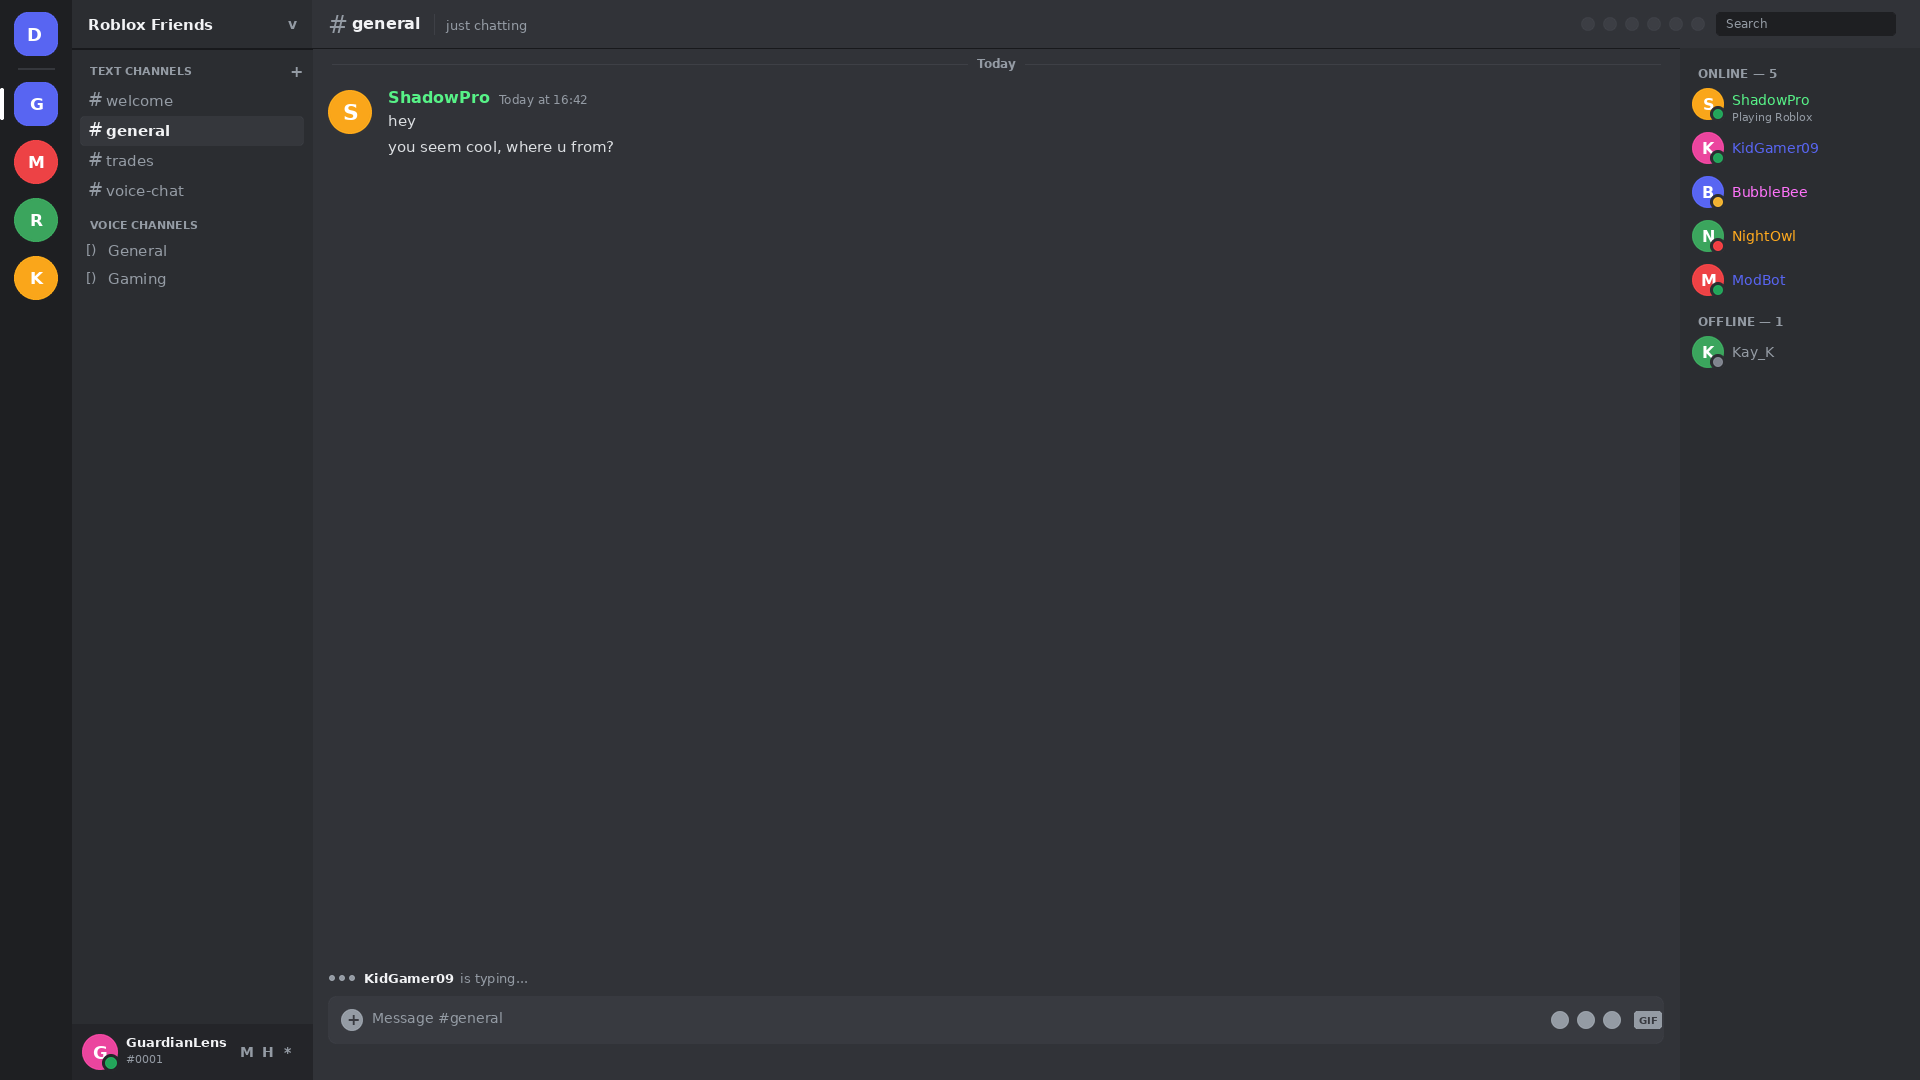

**Frame 3/9** — `frame_0003.png`

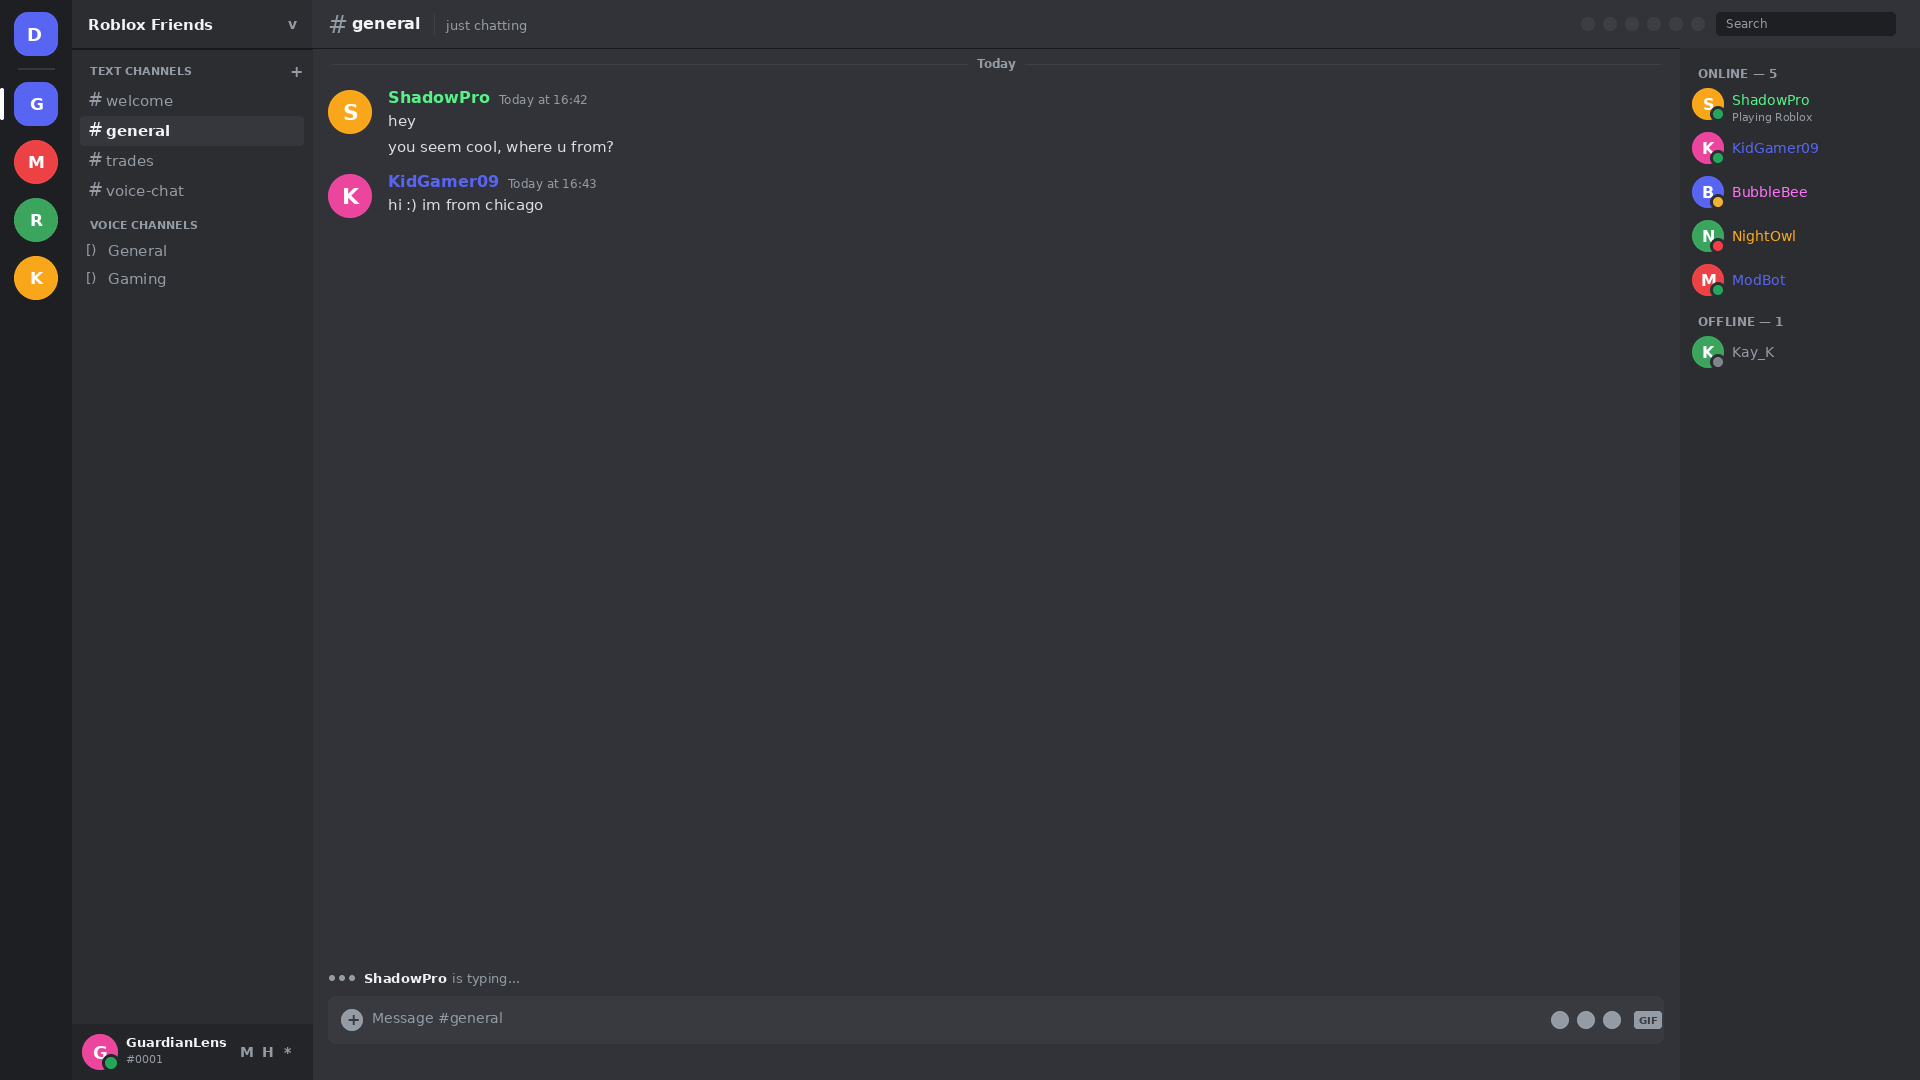

**Frame 4/9** — `frame_0004.png`

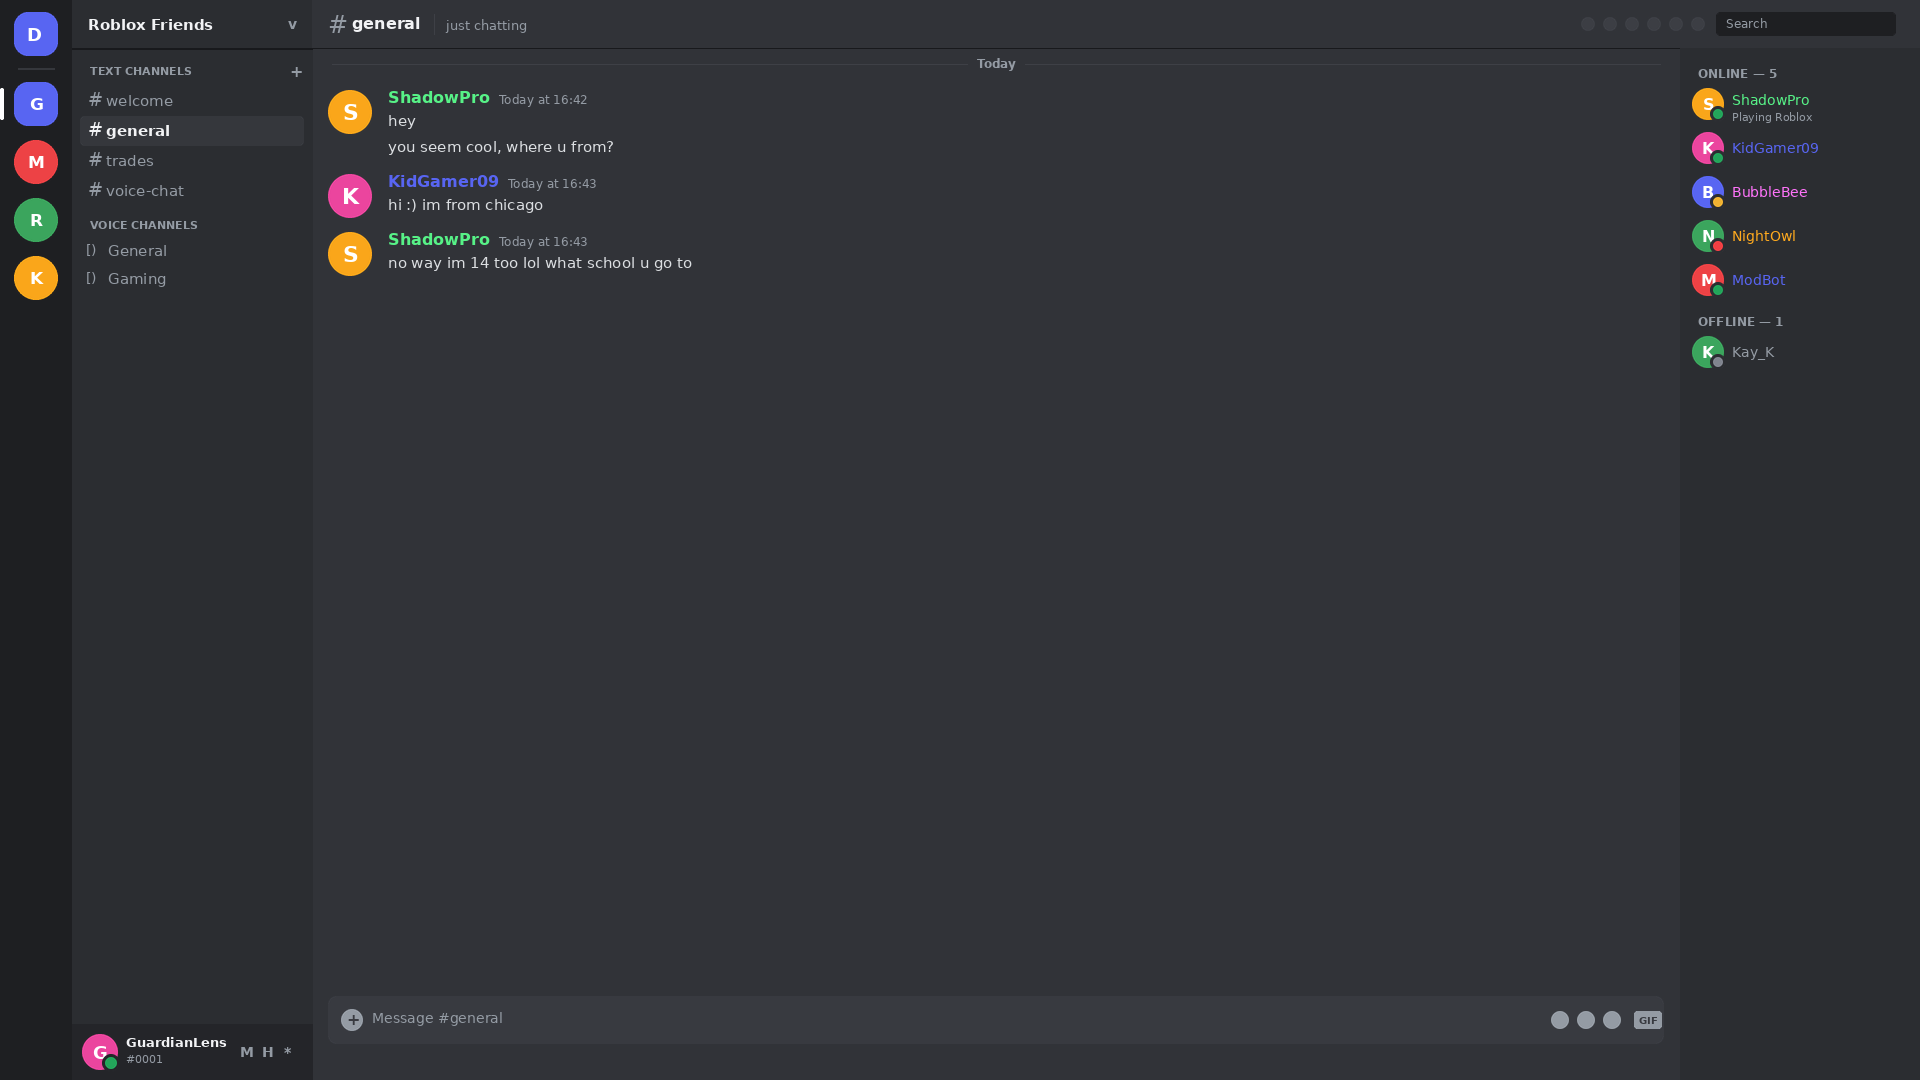

**Frame 5/9** — `frame_0005.png`

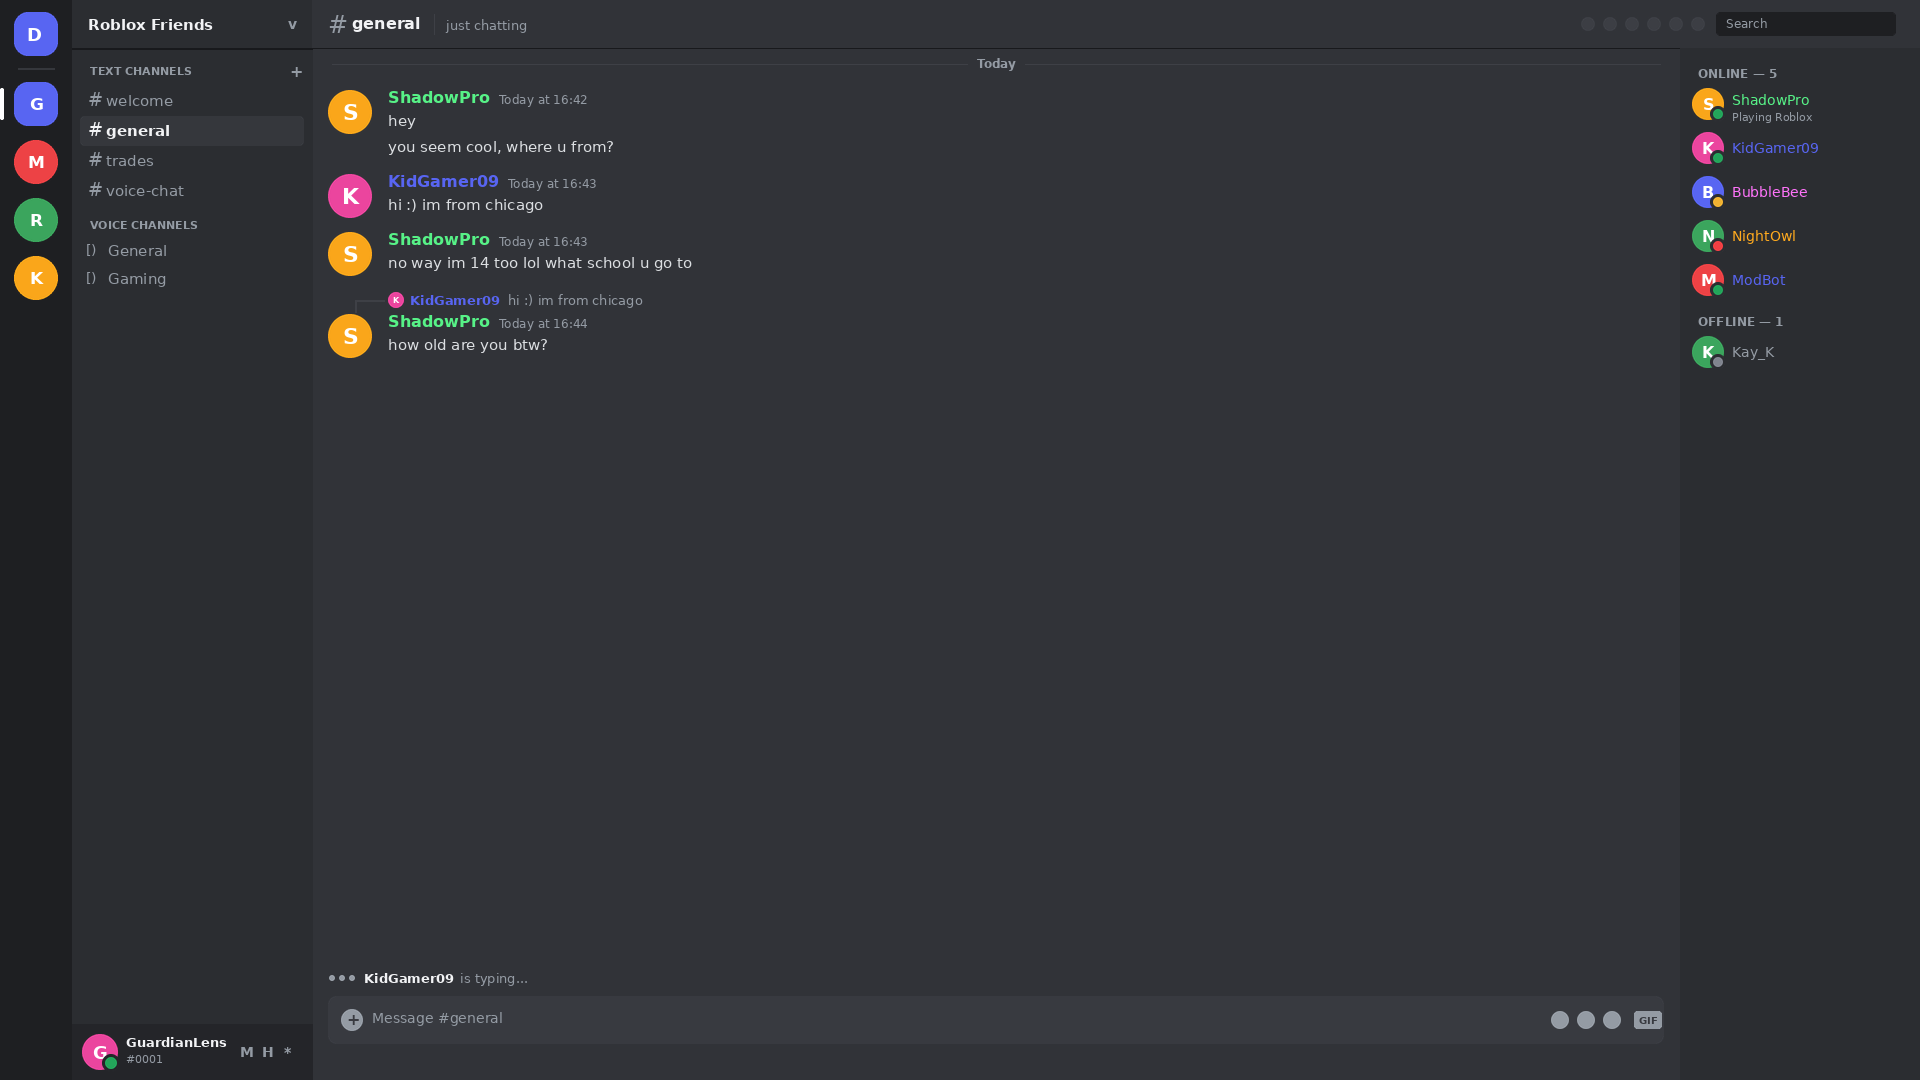

**Frame 6/9** — `frame_0006.png`

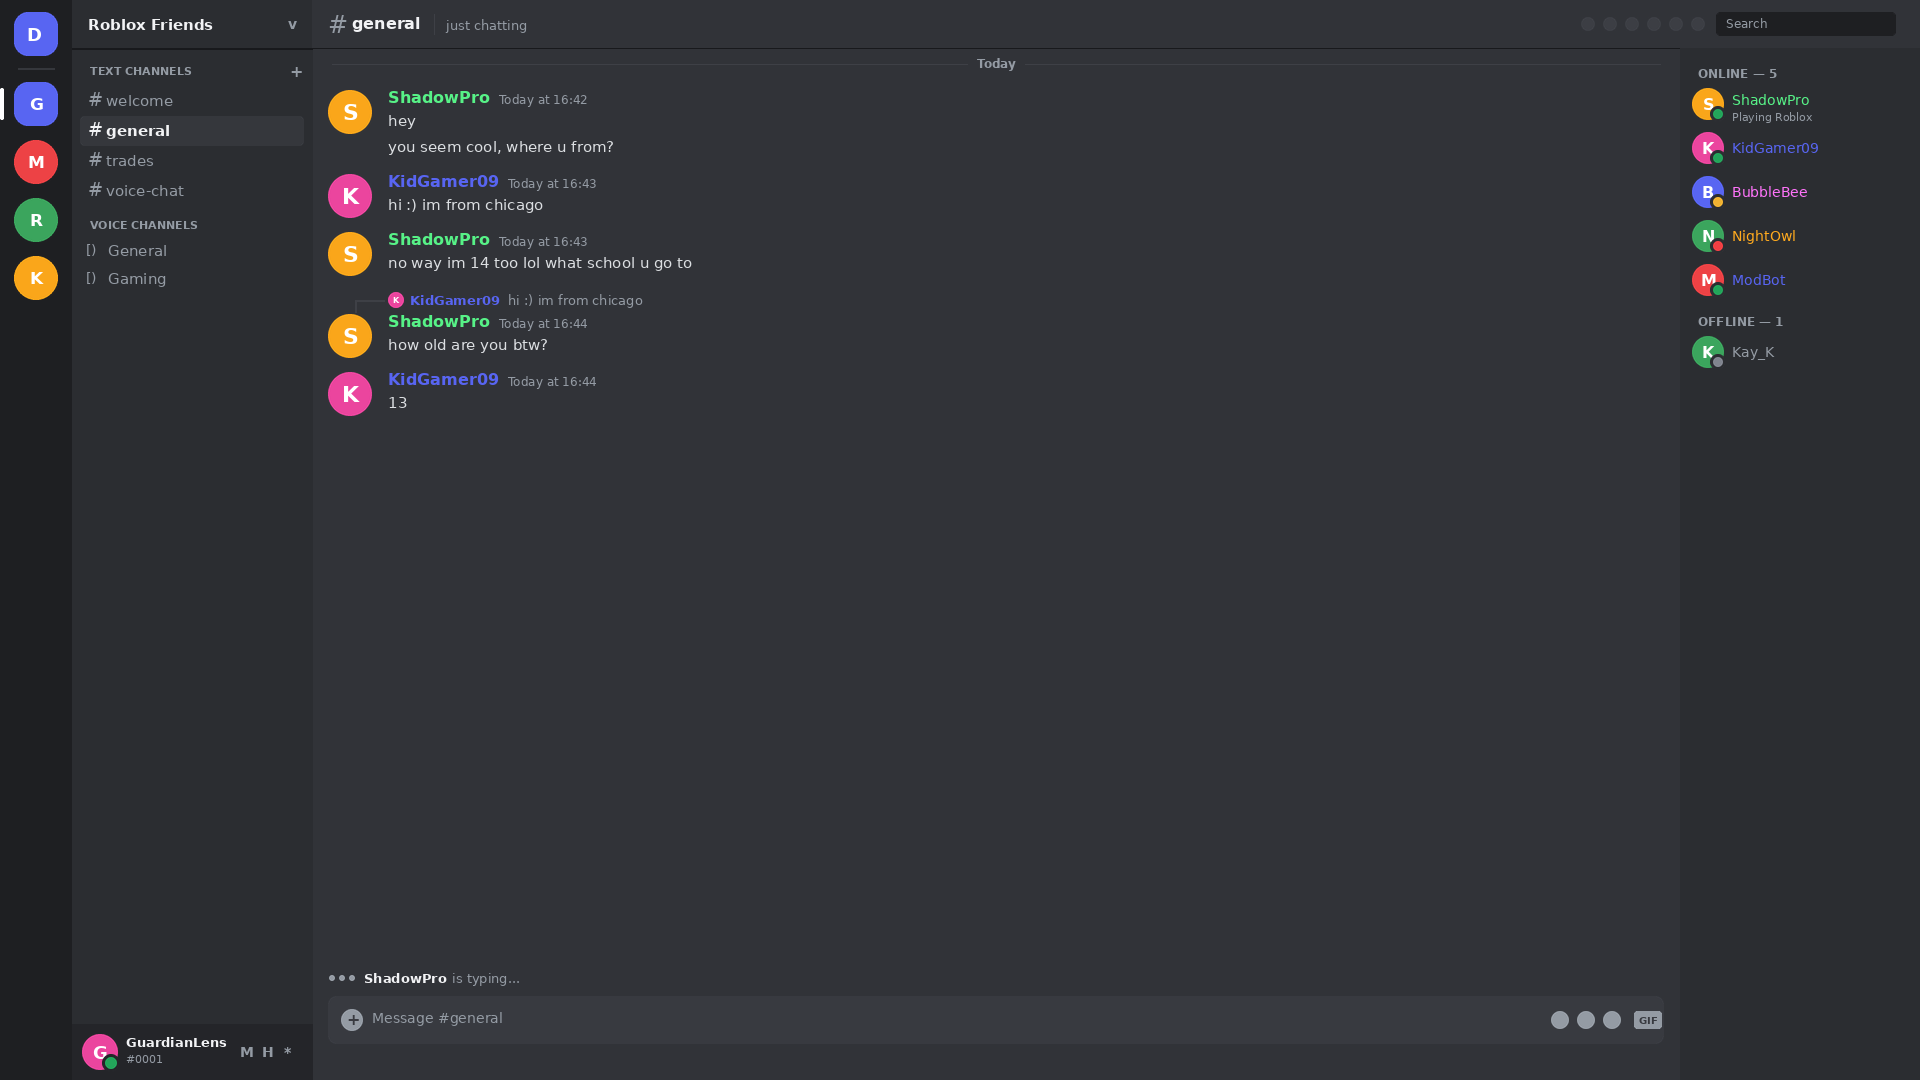

**Frame 7/9** — `frame_0007.png`

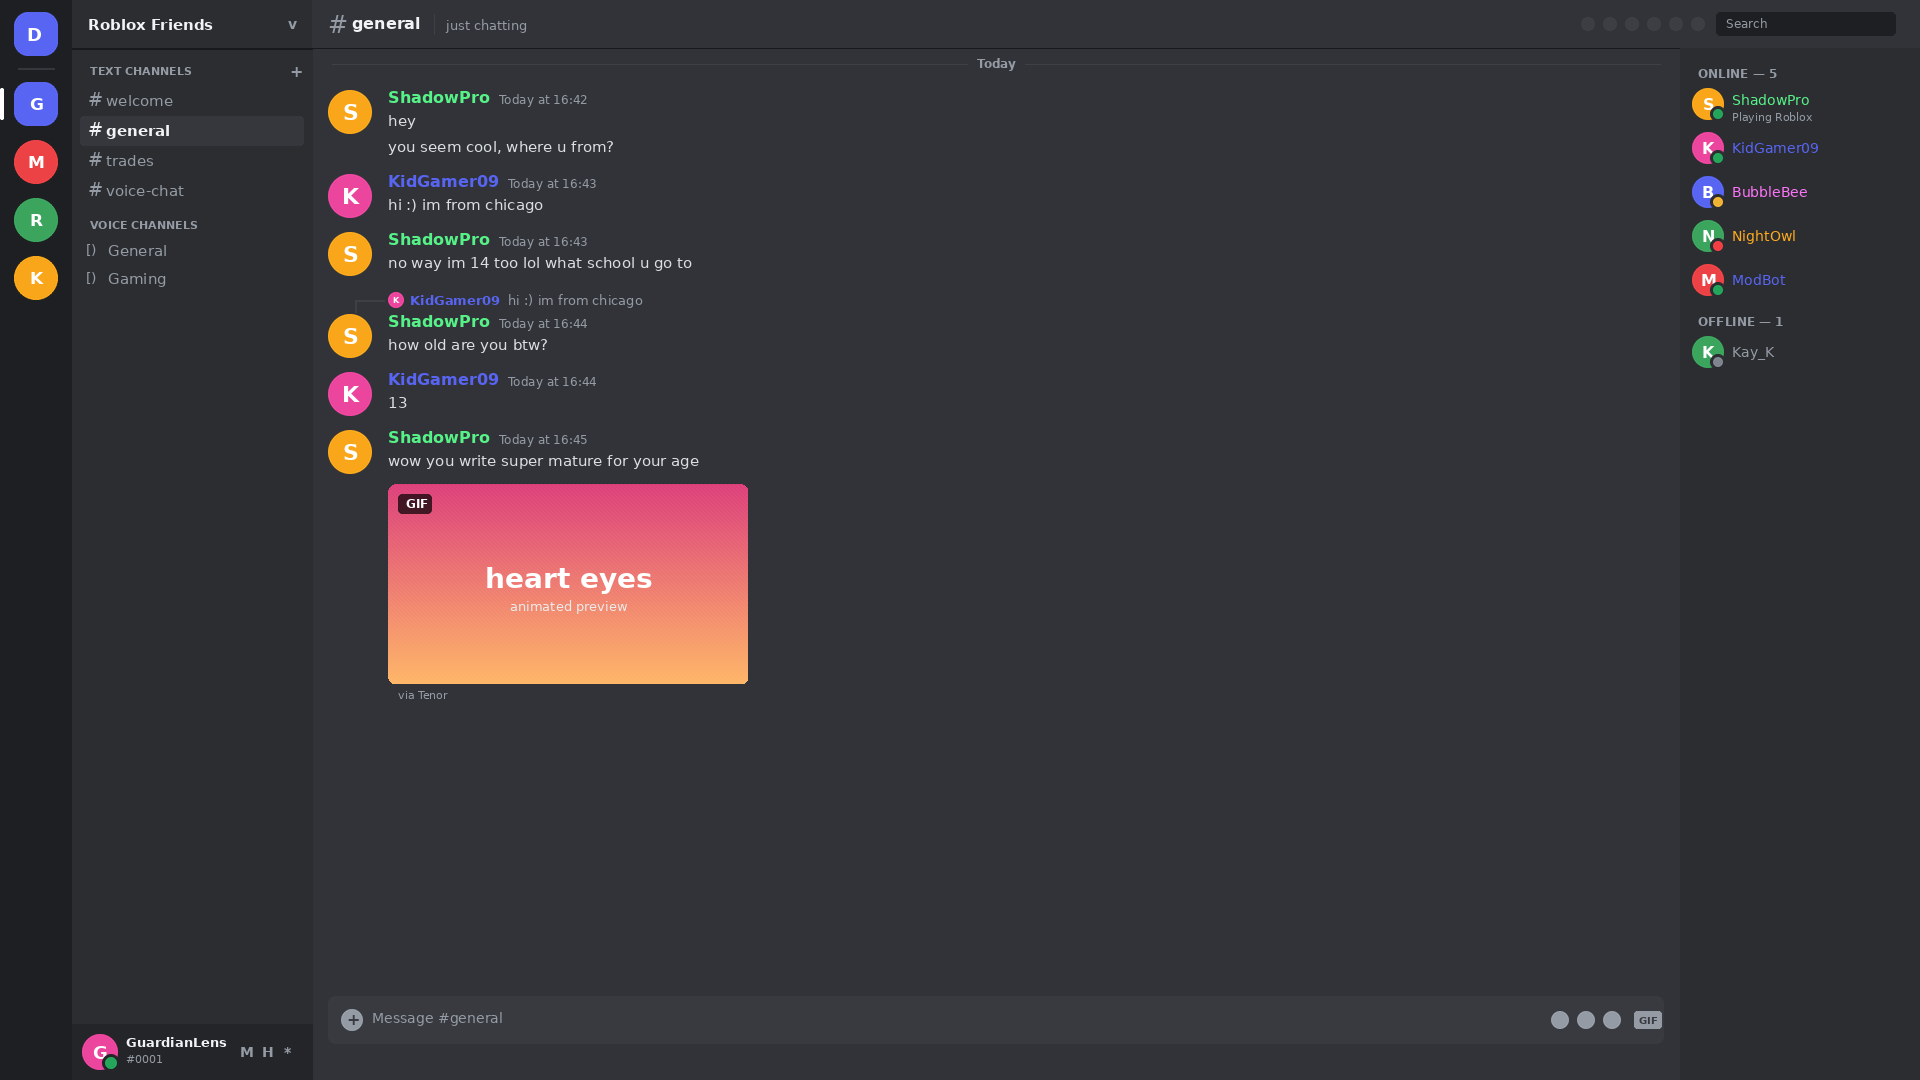

**Frame 8/9** — `frame_0008.png`

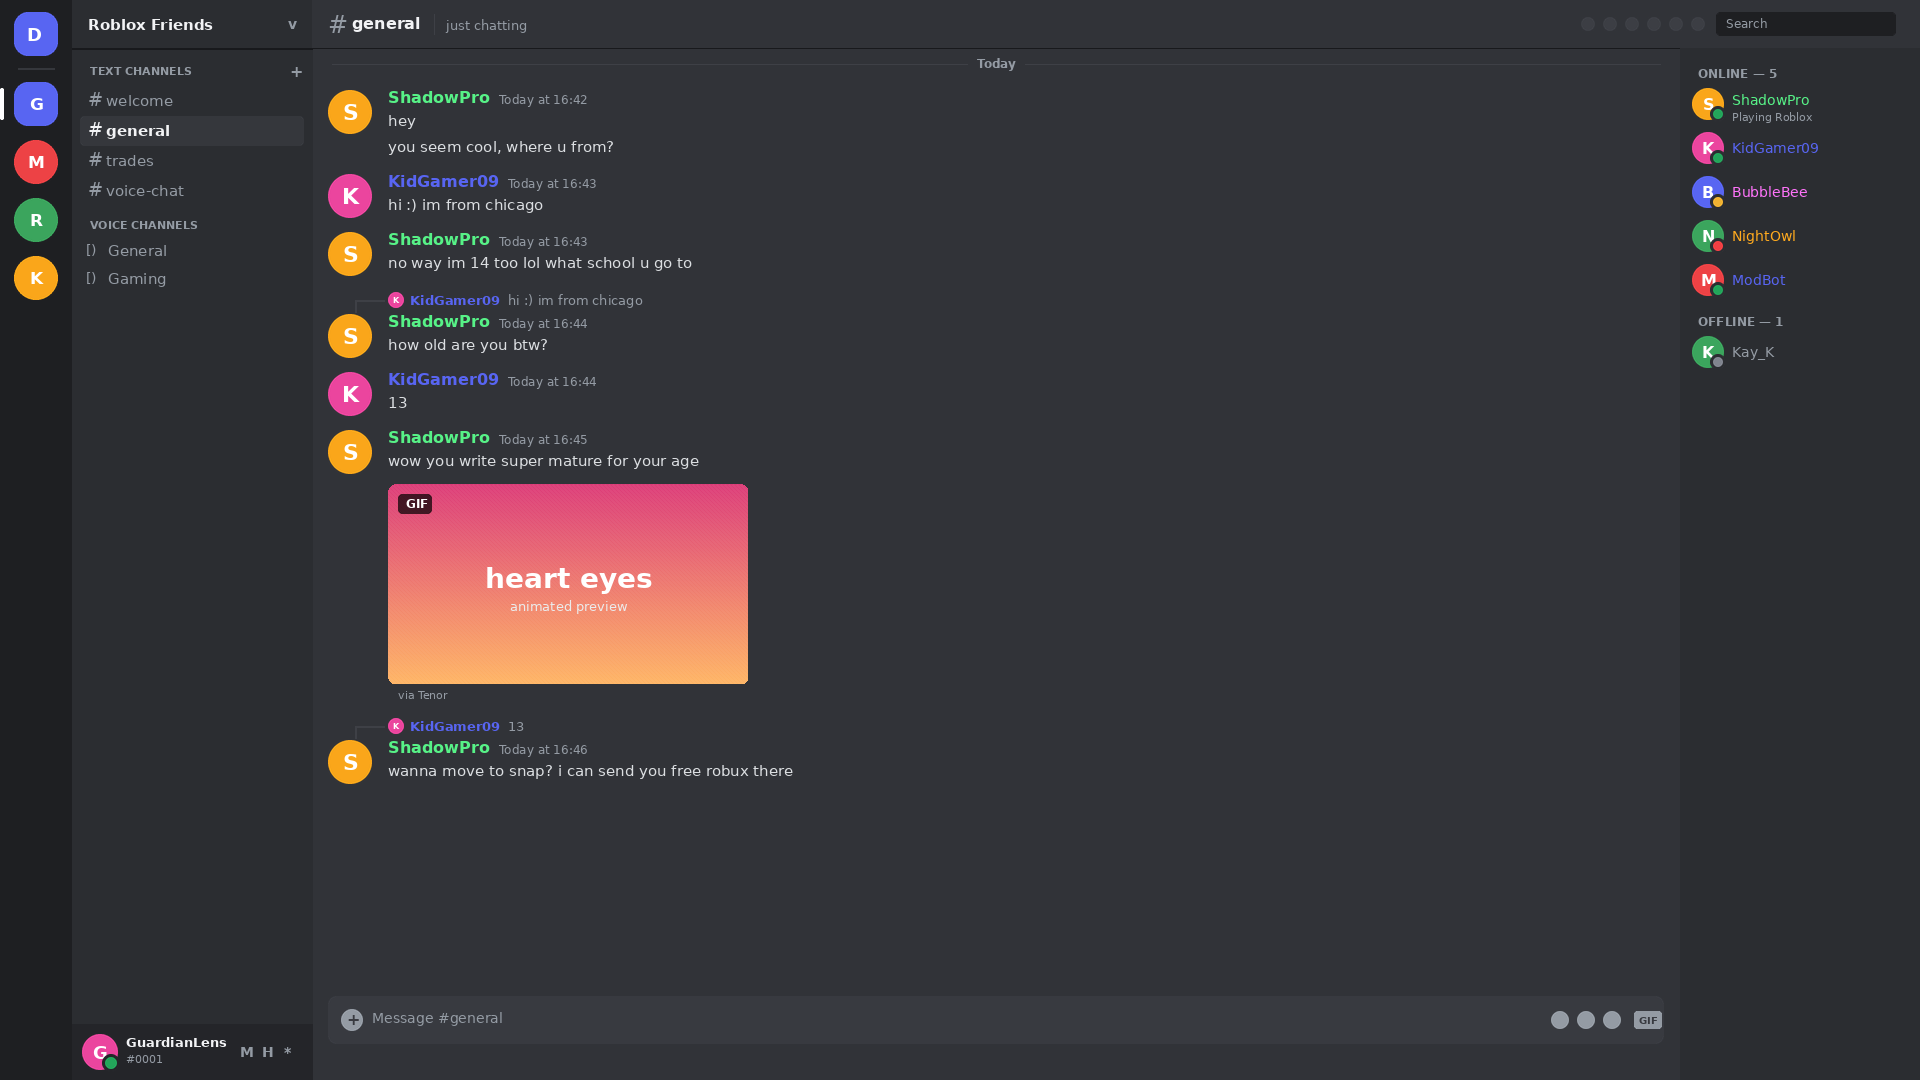

**Frame 9/9** — `frame_0009.png`

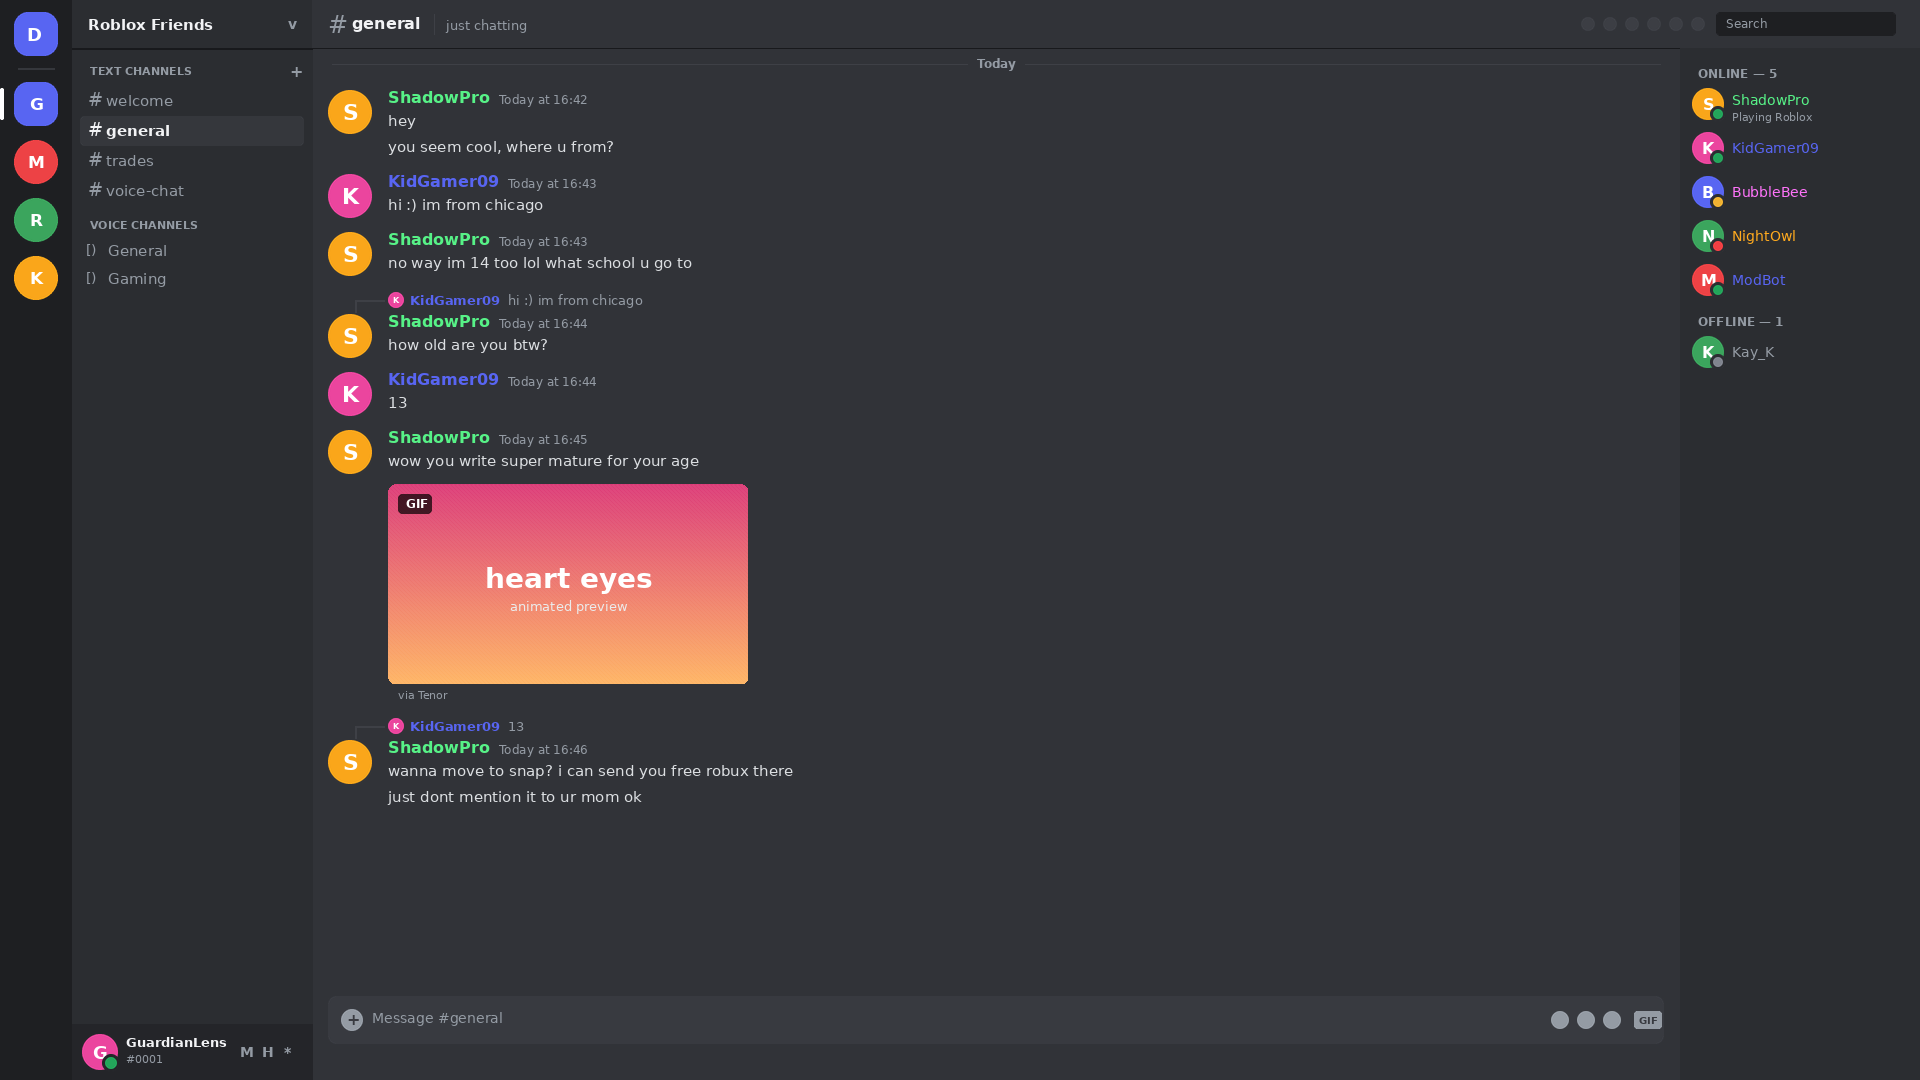

In [3]:
from IPython.display import Image, display, Markdown

SCENARIO = "grooming"
frames = rendered[SCENARIO]

display(Markdown(f"### {SCENARIO} — {len(frames)} frames"))
for idx, path in enumerate(frames, start=1):
    display(Markdown(f"**Frame {idx}/{len(frames)}** — `{path.name}`"))
    display(Image(filename=str(path), width=960))

## 4. Compile frames to MP4

Uses `ffmpeg` to turn each scenario's frame sequence into a playable clip. Each input frame is held for `SECONDS_PER_FRAME` seconds of output, so you can read the chat at a comfortable pace. Output is H.264, 960×540 (downscaled from 1920×1080 for a smaller preview), encoded with `yuv420p` pixel format so it plays directly inside Jupyter.

In [4]:
SECONDS_PER_FRAME = 2.0
OUTPUT_FPS = 30

VIDEO_DIR = PROJECT_ROOT / "outputs" / "discord_videos"
VIDEO_DIR.mkdir(parents=True, exist_ok=True)


def frames_to_mp4(
    frames_dir: Path,
    output_path: Path,
    seconds_per_frame: float = SECONDS_PER_FRAME,
    output_fps: int = OUTPUT_FPS,
    scale: str = "960:540",
) -> Path:
    """Compile numbered PNGs into an H.264 MP4 suitable for Jupyter preview."""
    input_framerate = 1.0 / seconds_per_frame
    cmd = [
        "ffmpeg",
        "-y",
        "-framerate", f"{input_framerate}",
        "-i", str(frames_dir / "frame_%04d.png"),
        "-r", str(output_fps),
        "-c:v", "libx264",
        "-pix_fmt", "yuv420p",
        "-vf", f"scale={scale}",
        "-crf", "22",
        "-preset", "veryfast",
        "-movflags", "+faststart",
        str(output_path),
    ]
    subprocess.run(cmd, check=True, capture_output=True)
    return output_path


videos = {}
for name, paths in rendered.items():
    frames_dir = paths[0].parent
    out_mp4 = VIDEO_DIR / f"discord_{name}.mp4"
    frames_to_mp4(frames_dir, out_mp4)
    size_kb = out_mp4.stat().st_size // 1024
    duration = len(paths) * SECONDS_PER_FRAME
    videos[name] = out_mp4
    print(f"  {name:10s} -> {out_mp4.relative_to(PROJECT_ROOT)} ({duration:.0f}s, {size_kb} KB)")

  bullying   -> outputs/discord_videos/discord_bullying.mp4 (16s, 49 KB)
  grooming   -> outputs/discord_videos/discord_grooming.mp4 (18s, 74 KB)
  safe       -> outputs/discord_videos/discord_safe.mp4 (14s, 54 KB)
  scam       -> outputs/discord_videos/discord_scam.mp4 (12s, 47 KB)


## 5. Play the videos inline

`IPython.display.Video(..., embed=True)` base64-encodes the MP4 into the notebook output so the clip plays even after the kernel is shut down and the notebook is reopened elsewhere.

In [5]:
from IPython.display import Video, display, Markdown

for name in ("safe", "grooming", "bullying", "scam"):
    display(Markdown(f"### discord_{name}.mp4"))
    display(Video(str(videos[name]), embed=True, width=720))

### discord_safe.mp4

### discord_grooming.mp4

### discord_bullying.mp4

### discord_scam.mp4

## 6. Final-frame comparison across scenarios

Side-by-side look at the last frame of each scenario so you can eyeball the visual spread the detector will see.

### safe — final frame

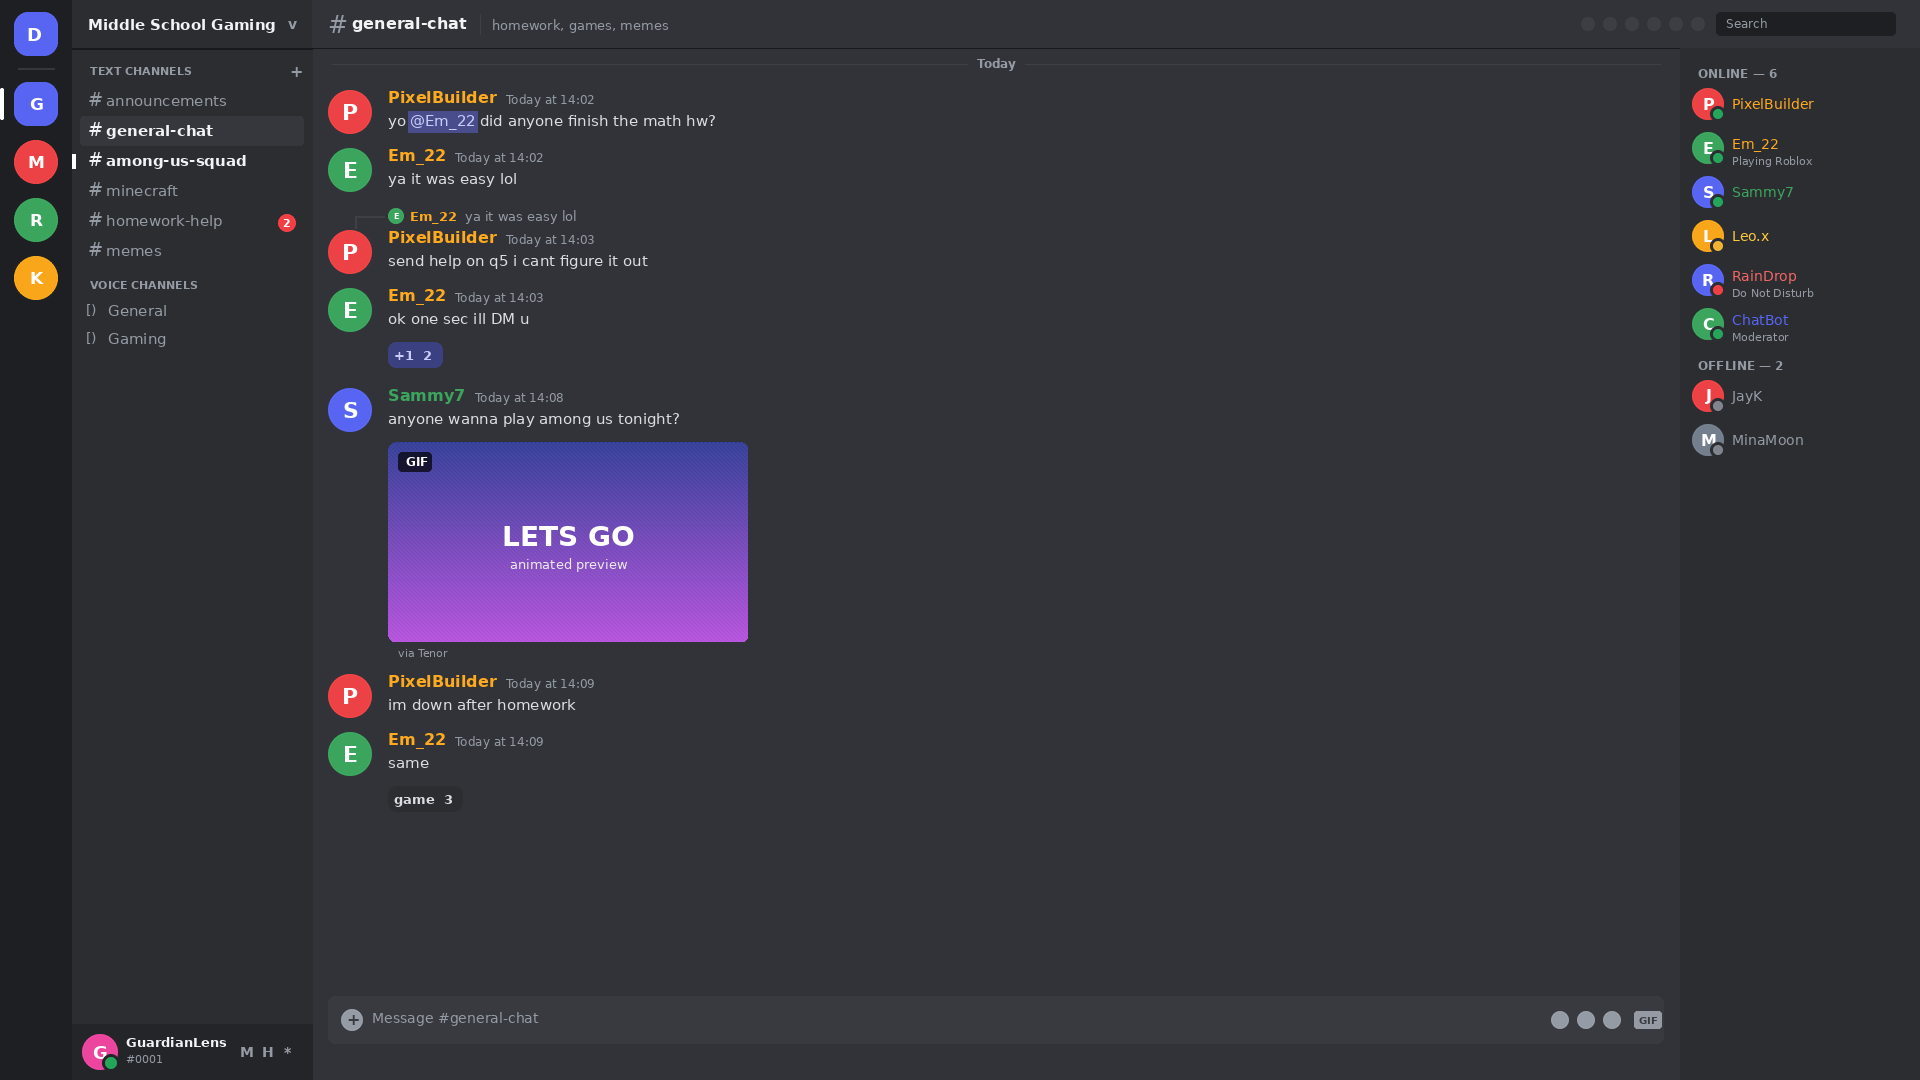

### grooming — final frame

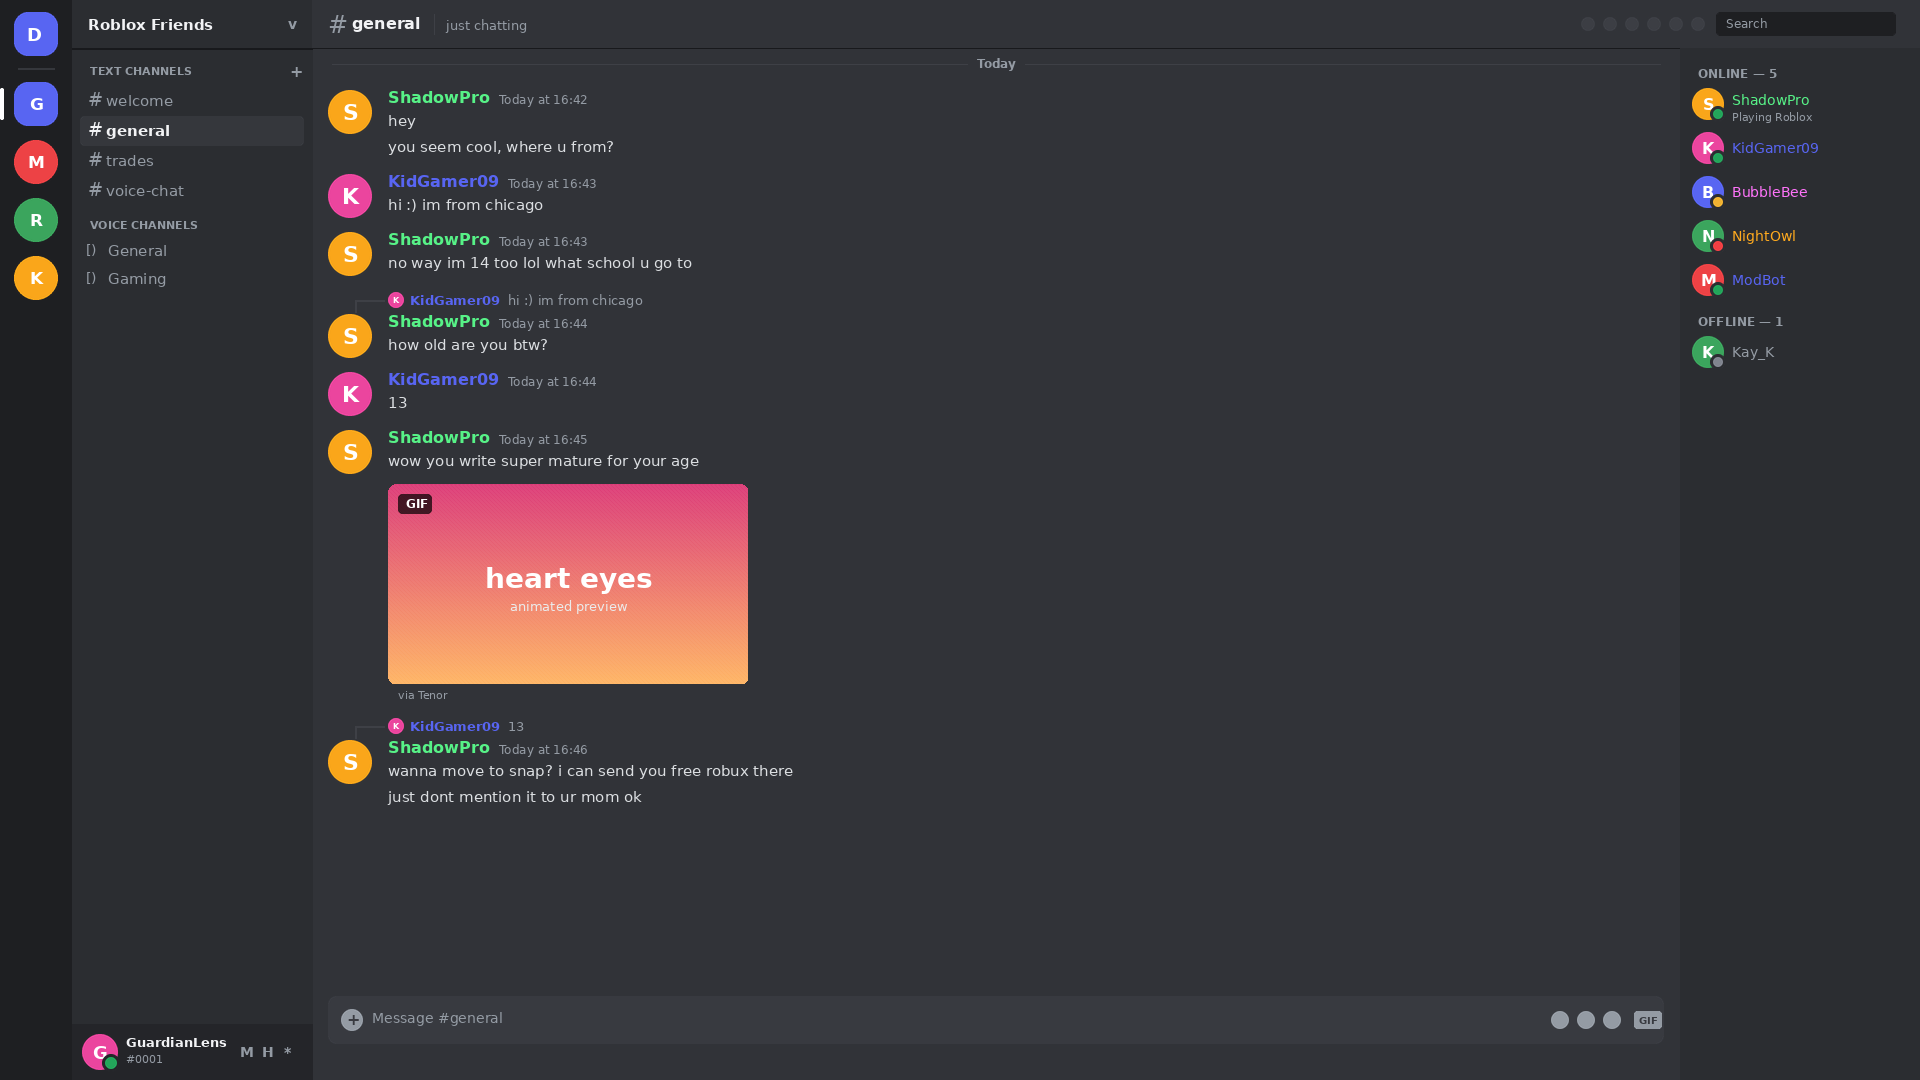

### bullying — final frame

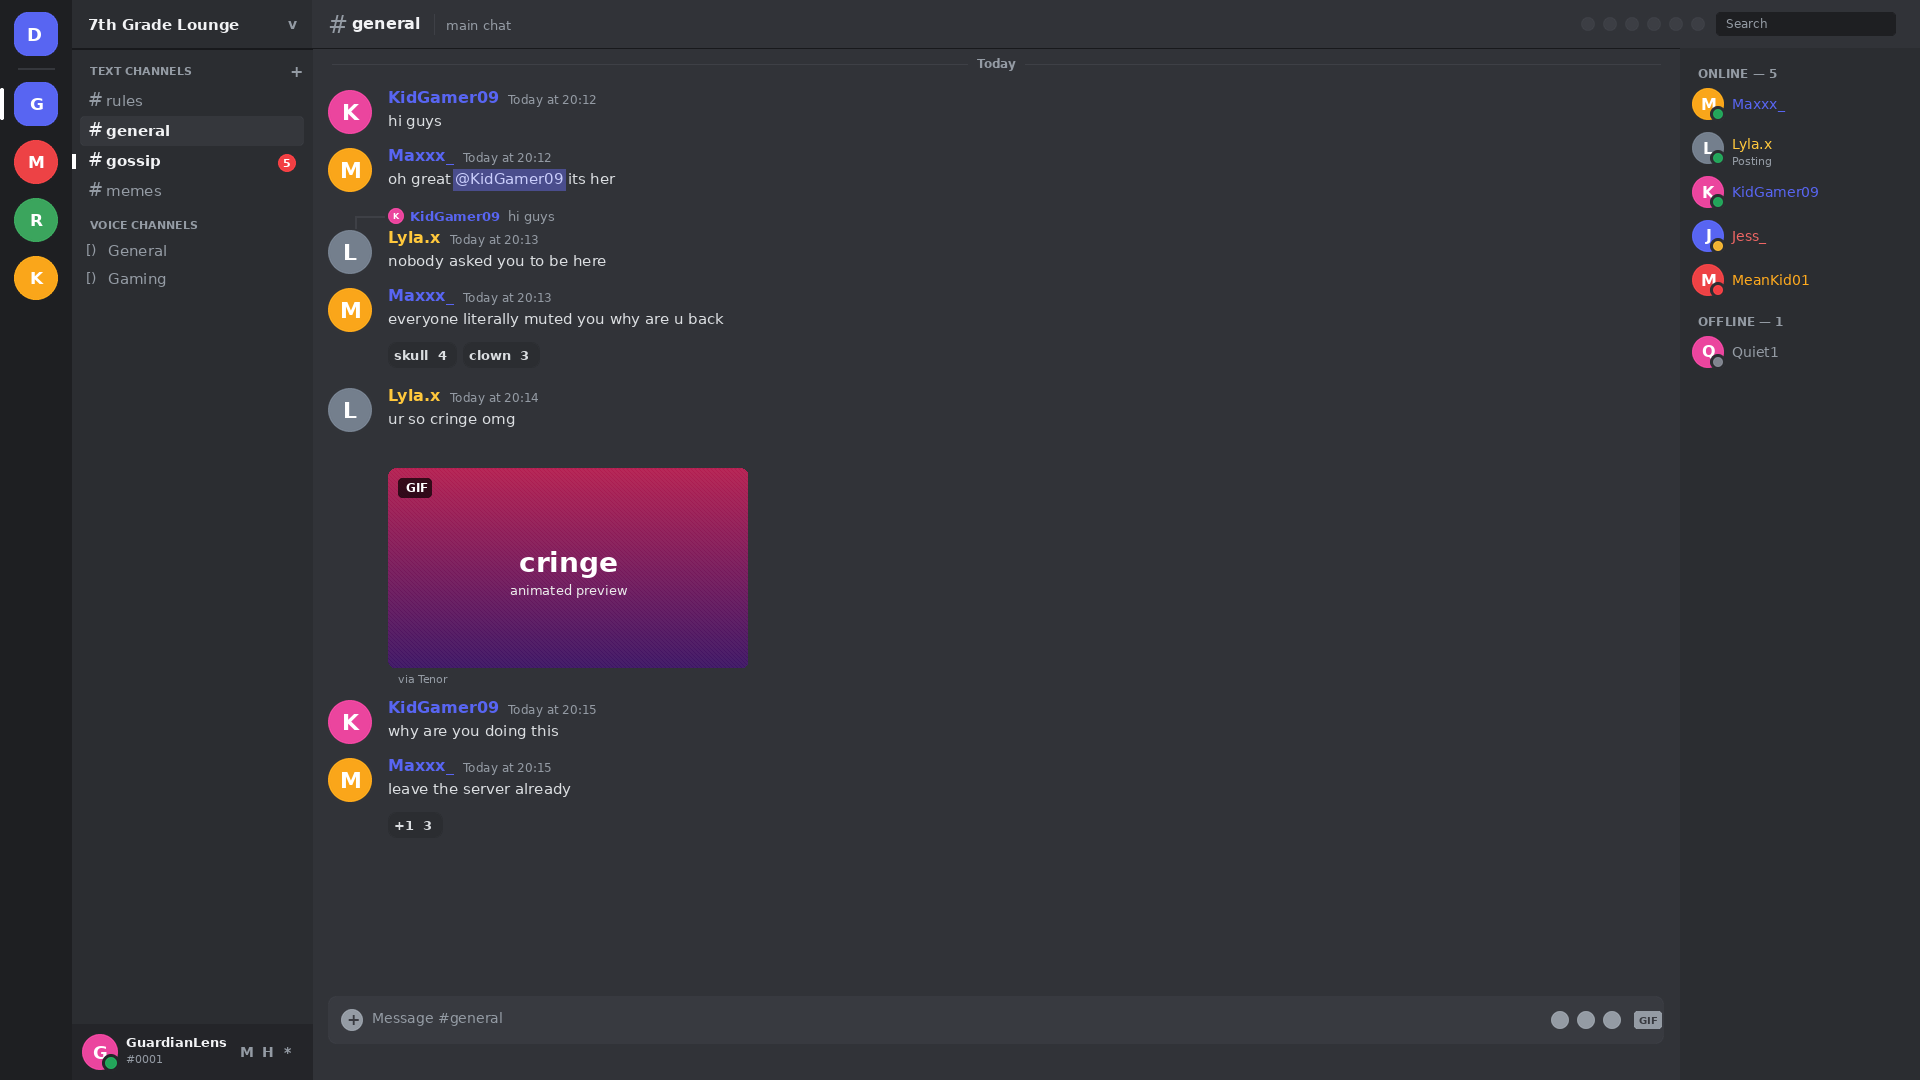

### scam — final frame

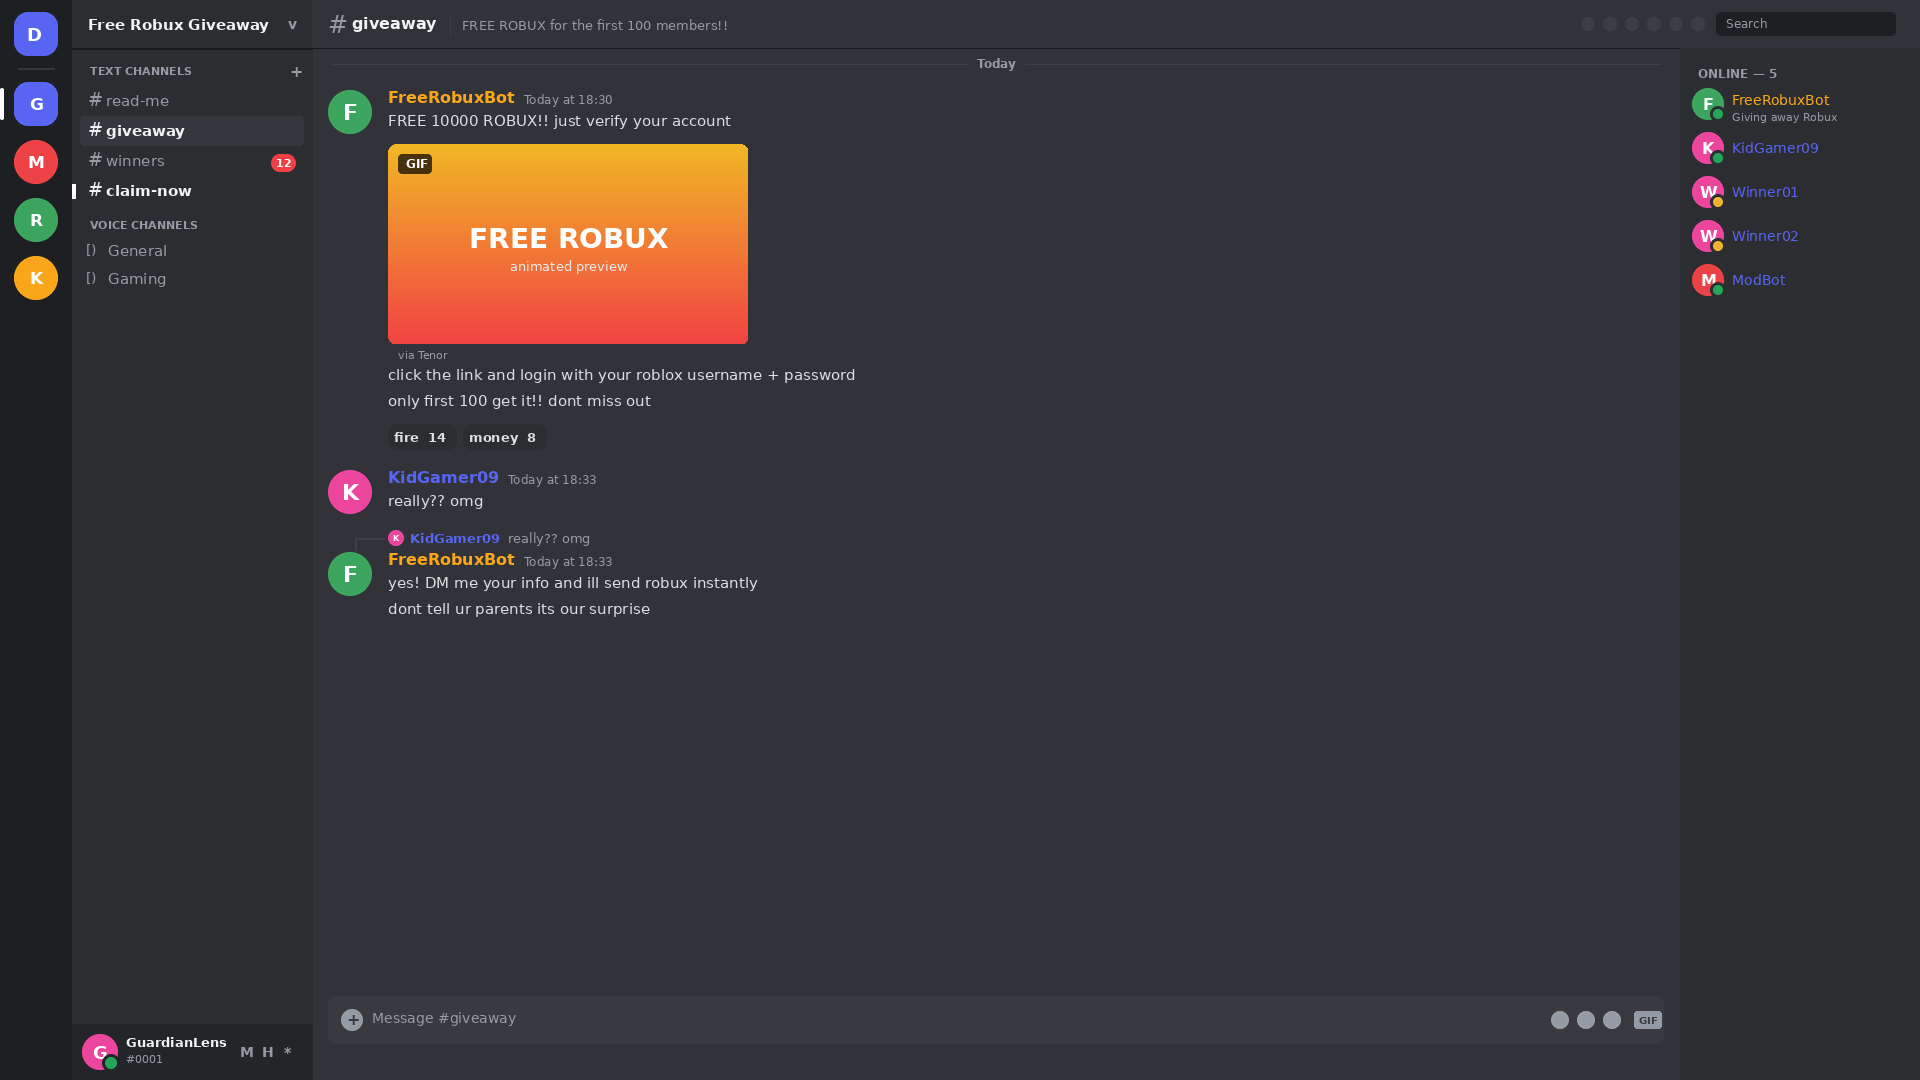

In [6]:
from IPython.display import Image, display, Markdown

for name in ("safe", "grooming", "bullying", "scam"):
    last_frame = rendered[name][-1]
    display(Markdown(f"### {name} — final frame"))
    display(Image(filename=str(last_frame), width=900))

## 7. Next step — feed a scenario to the live dashboard

The frames are now ready to drive the actual GuardianLens pipeline. From a terminal (not this notebook):

```bash
.venv/bin/python run.py \
    --watch-folder outputs/video_feeds/discord_grooming \
    --interval 2 \
    --model gemma4
```

Open `http://localhost:7860/` and watch the dashboard react as each frame is analysed. The grooming scenario should escalate through `safe → caution → alert` as the age question, compliment, and off-platform move land in sequence.